In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.inter_rater import fleiss_kappa

df = pd.read_csv('/Users/oscar-james/Documents/MyCourses/Project/Assignment/ProjectInDataScience2026_ExamTemplate_F/data/metadata.csv') #initalising the metatdata dataframe

ktype = ['SCC','BCC','MEL'] #cancer type

In [139]:
smokers = df.loc[df.smoke==True] #df of the smokers
nb_smokers = len(smokers) 
sk = smokers.loc[smokers.diagnostic.isin(ktype)] #smokers that have cancer
sk_percent = (len(sk)/len(smokers))*100 #percent of smokers having any cancer type

sk_percent

90.0

In [140]:
drinkers = df.loc[df.drink==True]
nb_drinkers = len(drinkers)
dk = drinkers.loc[drinkers.diagnostic.isin(ktype)]
dk_percent = (len(dk)/len(drinkers))*100

dk_percent

76.0

In [141]:

annotations = pd.read_excel('/Users/oscar-james/Documents/MyCourses/Project/Assignment/ProjectInDataScience2026_ExamTemplate_F/results/reports/GroupeF_annotation.xlsx')

cols_hair = ["Hair_h :", "Hair_j :", "Hair_n :", "Hair_oj :", "Hair_v :"]
data_h = annotations[cols_hair]
categories_h = sorted(pd.unique(data_h.values.ravel()))
table = []
for _, row in data_h.iterrows():
    counts = [(row == c).sum() for c in categories_h]
    table.append(counts)
kappa_h = fleiss_kappa(table)

print("Fleiss' Kappa (Hair):", kappa_h)

cols_pen = ['Pen_h :', 'Pen_j :','Pen_n :', 'Pen_oj :', 'Pen_v :']
data_p = annotations[cols_pen]
categories_p = sorted(pd.unique(data_p.values.ravel()))
table = []
for _, row in data_p.iterrows():
    counts = [(row == c).sum() for c in categories_p]
    table.append(counts)
kappa_p = fleiss_kappa(table)

print("Fleiss' Kappa (Hair):", kappa_p)

Fleiss' Kappa (Hair): 0.4462694877505569
Fleiss' Kappa (Hair): 0.896442645157318


<Axes: title={'center': 'Age Distribution'}, xlabel='age', ylabel='number of malignus cancer'>

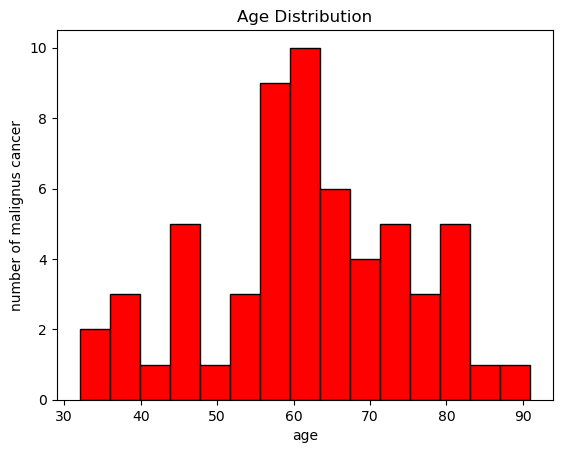

In [144]:
malignus_df=df[(df["diagnostic"]=="MEL")|(df["diagnostic"]=="BCC")|(df["diagnostic"]=="SCC")]
malignus_df['age'].plot(kind='hist', bins=15, title='Age Distribution', color='red', edgecolor= 'black', xlabel="age", ylabel="number of malignus cancer")

background_father
POMERANIA      23
GERMANY        17
ITALY           7
UNK             5
BRAZIL          5
PORTUGAL        1
NETHERLANDS     1
Name: count, dtype: int64


background_mother
POMERANIA      23
GERMANY        17
ITALY           6
BRAZIL          6
UNK             5
NORWAY          1
NETHERLANDS     1
Name: count, dtype: int64


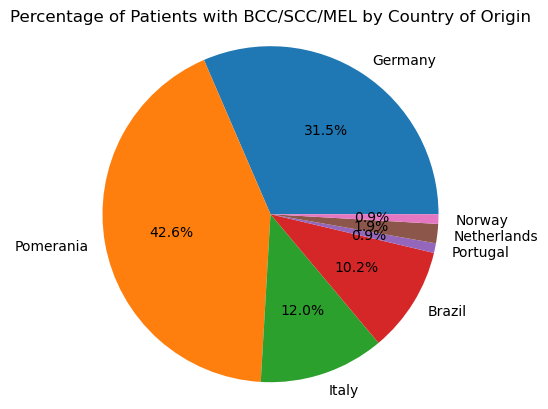

In [145]:
total_bcc_scc = len(df.loc[df.diagnostic.isin(ktype)])
father_bg = df[df['diagnostic'].isin(['BCC', 'SCC', 'MEL'])]['background_father'].value_counts()
mother_bg = df[df['diagnostic'].isin(['BCC', 'SCC', 'MEL'])]['background_mother'].value_counts()
print(father_bg)
print("\n")
print(mother_bg)
 
percentage_germany = (father_bg['GERMANY'] + mother_bg['GERMANY']) / (2 * total_bcc_scc) * 100
percentage_pomerania = (father_bg['POMERANIA'] + mother_bg['POMERANIA']) / (2 * total_bcc_scc) * 100
percentage_italy = (father_bg['ITALY'] + mother_bg['ITALY']) / (2 * total_bcc_scc) * 100
percentage_brazil = (father_bg['BRAZIL'] + mother_bg['BRAZIL']) / (2 * total_bcc_scc) * 100
percentage_portugal = father_bg['PORTUGAL']/ (2 * total_bcc_scc) * 100
percentage_netherlands = (father_bg['NETHERLANDS'] + mother_bg['NETHERLANDS']) / (2 * total_bcc_scc) * 100
percentage_norway = mother_bg['NORWAY'] / (2 * total_bcc_scc) * 100
 
plt.pie([percentage_germany, percentage_pomerania, percentage_italy, percentage_brazil, percentage_portugal, percentage_netherlands, percentage_norway], labels=['Germany', 'Pomerania', 'Italy', 'Brazil', 'Portugal', 'Netherlands', 'Norway'], autopct='%1.1f%%')
plt.title('Percentage of Patients with BCC/SCC/MEL by Country of Origin')
plt.axis('equal')
plt.show()